# Data Loading

In [9]:
import pandas as pd

data = pd.read_csv("predictions.csv", index_col = 0)
data.rename(columns={"pIC50": "real pIC50", "y_pred": "predicted pIC50"}, inplace=True)
data = data[["target_organism", "real pIC50", "predicted pIC50"]]
data.head()

,target_organism,real pIC50,predicted pIC50
3218,Salmonella enterica subsp. enterica serovar Ty...,1.501689,1.610187
9448,Staphylococcus aureus,1.966172,2.880857
2491,Raoultella planticola,2.958607,3.353389
319,Salmonella enterica subsp. enterica serovar Ty...,1.478862,1.553982
508,Staphylococcus aureus,1.271646,1.513311


# Prediction Analysis

## Metrics

In [10]:
y_real = data["real pIC50"]
y_pred = data["predicted pIC50"]

from sklearn.metrics import r2_score, mean_squared_error
print("R² score: ", r2_score(y_real, y_pred))
print("MSE: ", mean_squared_error(y_real, y_pred))
print("RMSE:", mean_squared_error(y_real, y_pred)**0.5)

R² score:  0.5725399189703154
MSE:  0.21071817038890753
RMSE: 0.4590404888339454


# Graph

Text(0, 0.5, 'predicted pIC50')

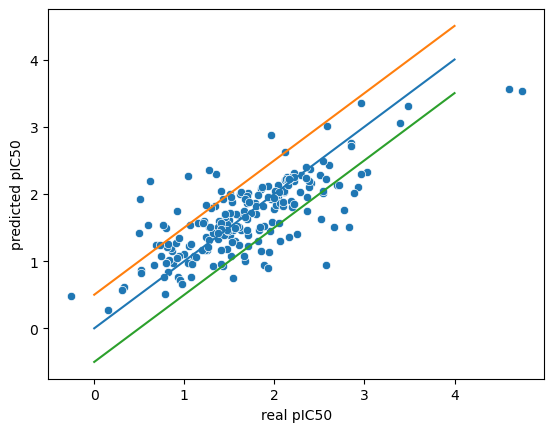

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = y_real, y= y_pred)
sns.lineplot(x = [0,4], y=[0,4])
sns.lineplot(x = [0,4], y=[0.5, 4.5])
sns.lineplot(x = [0,4], y=[-0.5, 3.5])
plt.xlabel('real pIC50')
plt.ylabel('predicted pIC50')

<Axes: ylabel='Count'>

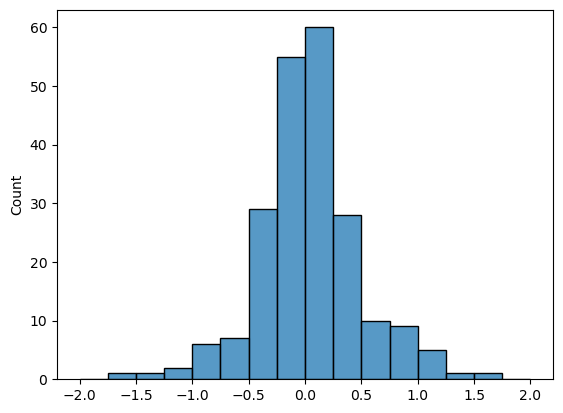

In [12]:
sns.histplot((y_real-y_pred), bins=16, binrange=(-2, 2))

## RESULTS BY SPECIES

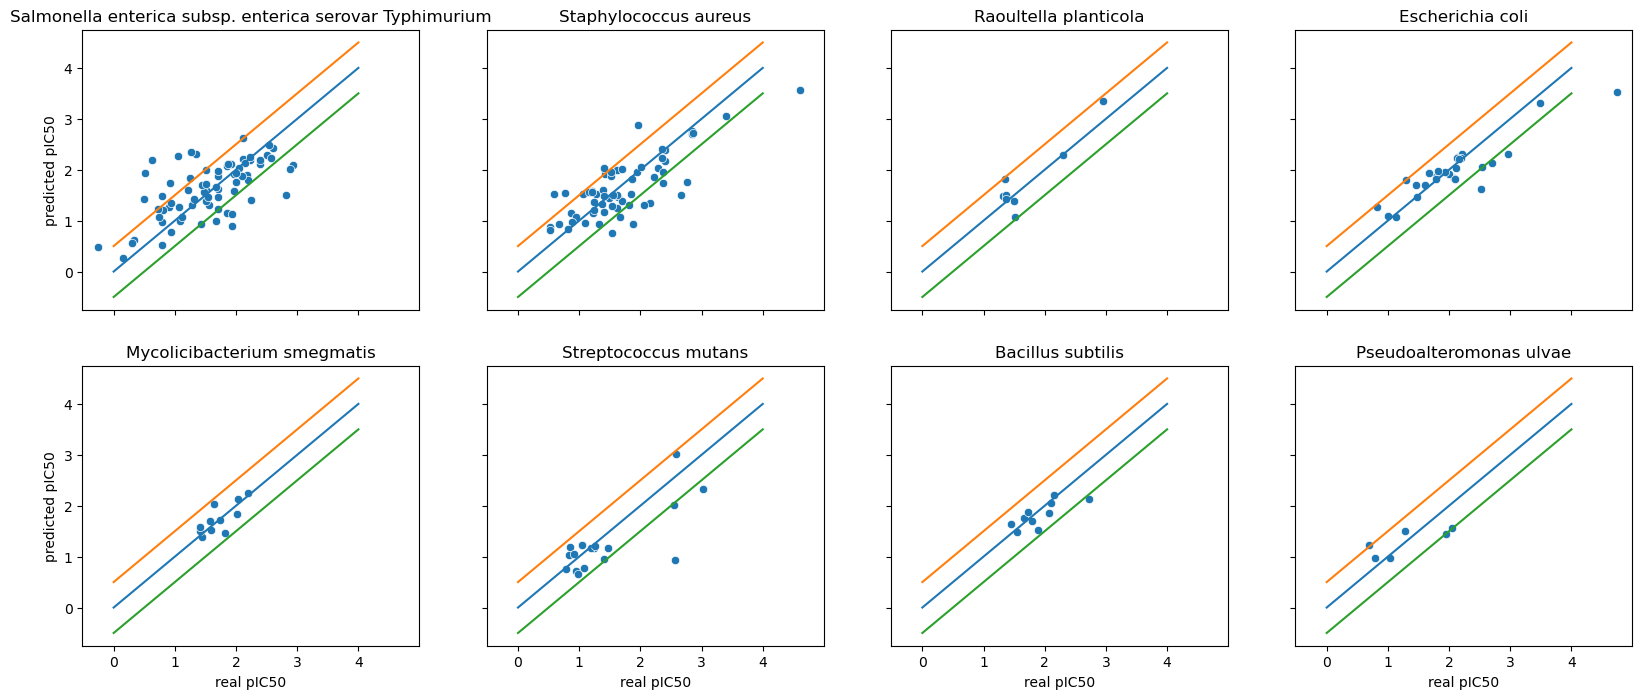

In [13]:
fig, axes = plt.subplots(2, 4, sharex="all", sharey="all", figsize = (20, 8))
for i, specie in enumerate(data.target_organism.unique()):
    ax = axes[i//4][i%4]
    sns.scatterplot(data[data.target_organism.eq(specie)], x="real pIC50", y="predicted pIC50", ax=ax)
    sns.lineplot(x = [0,4], y=[0,4], ax=ax)
    sns.lineplot(x = [0,4], y=[0.5, 4.5], ax=ax)
    sns.lineplot(x = [0,4], y=[-0.5, 3.5], ax=ax)
    ax.set_title(specie)

In [14]:
from collections import defaultdict

metrics = defaultdict(dict)

for specie in data.target_organism.unique():
    subdata = data[data.target_organism.eq(specie)]
    y = subdata["real pIC50"]
    y_pred = subdata["predicted pIC50"]
    metrics["R2"][specie] = r2_score(y, y_pred)
    metrics["MSE"][specie] =  mean_squared_error(y, y_pred)
    metrics["RMSE"][specie] =  mean_squared_error(y, y_pred)**0.5

metrics = pd.DataFrame(metrics)

metrics

,R2,MSE,RMSE
Salmonella enterica subsp. enterica serovar Typhimurium,0.383563,0.286362,0.535128
Staphylococcus aureus,0.605100,0.211950,0.460380
Raoultella planticola,0.742326,0.080367,0.283490
Escherichia coli,0.749224,0.151751,0.389553
Mycolicibacterium smegmatis,0.472312,0.035680,0.188890
Streptococcus mutans,0.494059,0.256277,0.506239
Bacillus subtilis,0.499583,0.061474,0.247939
Pseudoalteromonas ulvae,0.484436,0.144766,0.380482
